# AIT-ADS baseline comparison

Compares eleven system-task baselines evaluated on one AIT-ADS scenario's train/test split -- the AIT-ADS counterpart to `notebooks/baselines/cscas_baseline_comparison.ipynb` (see `baselines/_ait_ads_data.py`, `baselines/ait_ads_rf.py`, `baselines/ait_ads_logreg.py`, `baselines/ait_ads_xgboost.py`, `baselines/ait_ads_bert.py`, `baselines/ait_ads_securebert.py`, `baselines/ait_ads_zeroshot.py`, `baselines/ait_ads_anomaly.py`, `baselines/ait_ads_anomaly_iforest.py`, `baselines/ait_ads_mining.py`, `baselines/ait_ads_mining_anomaly.py`, `baselines/ait_ads_mining_anomaly_iforest.py`):

1. **Base schema (RF)** -- 5-feature `base` schema, `RandomForestClassifier`
2. **Base schema (LogReg)** -- same, `StandardScaler` + `LogisticRegression`
3. **Base schema (XGBoost)** -- same, `XGBClassifier`
4. **BERT** -- alert_group tokens (`sig:`/`host:`/`short:`) serialized to text, fine-tuned DistilBERT
5. **SecureBERT 2.0** -- same tokens, fine-tuned SecureBERT 2.0 (ModernBERT architecture, domain-adapted)
6. **Zero-shot** -- same tokens serialized to a prompt, no fine-tuning
7. **Anomaly (OneClassSVM)** -- same 5-feature base schema, `OneClassSVM` fit on benign-only train rows -- see the exclusion paragraph below for why this one is included as its own method rather than folded into the other six.
8. **Anomaly (IsolationForest)** -- same 5-feature base schema, benign-only fit, second anomaly-detector model family alongside method 7 -- isolates model choice within the anomaly-detector family the same way LogReg/XGBoost do within the classifier family. Tree-based, so unlike OneClassSVM it needs no feature scaling.
9. **Base schema + Mining (RF)** -- the same 5-feature base schema extended with symbolic features mined by the attribute-mining pipeline (contrast-set + decision-tree rules) on the identical train split, `RandomForestClassifier` -- the mining sibling of methods 1-3, and the AIT-ADS counterpart of CSCAS's `cscas_mining.py`.
10. **Anomaly + Mining (OneClassSVM)** -- method 9's mined symbolic features, on top of the reduced base schema, `OneClassSVM` fit on benign-only train rows -- the mining sibling of method 7, and the most complete "system" scenario (mining + task, one-class) evaluated here.
11. **Anomaly + Mining (IsolationForest)** -- method 9's mined symbolic features on the reduced base schema, `IsolationForest` fit on benign-only train rows -- the IsolationForest sibling of method 10 (and of method 8), 5-seeded (`random_state=0..4`).

**Two training-pool conditions, not three**: random undersampling and class-weighted (natural-ratio). No "guided" condition here -- AIT-ADS has no SCAS-equivalent outlier signal to guide sampling with (CSCAS-only, see `baselines/_sampling.py`'s own docstring). Zero-shot and all four anomaly methods have no training-pool step, so none of the conditions apply to them. Zero-shot and the two **OneClassSVM** anomaly methods are single deterministic runs (OneClassSVM has no `random_state`; its per-seed sd is exactly 0); the two **IsolationForest** anomaly methods are seed-averaged over 5 seeds like the classifiers. Every anomaly method reports `auc` alongside precision/recall/f1, plus `workload_at_recall` -- precision / FP / analyst-workload-reduction at the threshold hitting each target recall -- since the default `nu`/`contamination` = 0.05 cut over-flags relative to the true attack prevalence.

All methods are **seed-averaged (`N_SEEDS = 5`)** except zero-shot and the two OneClassSVM anomaly methods (single deterministic runs -- zero-shot at temperature=0, OneClassSVM has no `random_state` to average over). The two IsolationForest anomaly methods run the same 5-seed protocol (`random_state=0..4`), same convention as the CSCAS scripts.

**All ten methods share the exact same split** -- every script calls `_ait_ads_data.load_ait_ads_baseline_split(scenario, grouping_method)` (the two mining scripts use `load_ait_ads_baseline_split_with_groups`, the same split plus the AlertGroup objects mining needs), so results are directly comparable across model families for a given `(SCENARIO, GROUPING_METHOD)`, not just similarly configured pipelines. This replaced an earlier approach that pulled RF/LogReg/XGBoost from a separate, fixed_window-only pipeline (`run_model_comparison_attribute.py`) -- that could only ever guarantee *similar* splits, not identical ones, and couldn't be extended to the other 4 grouping methods without duplicating this same split logic anyway.

Results are **per (grouping method, scenario)** -- unlike CSCAS (pregrouped), AIT-ADS alerts need a grouping step first, and which of the 5 grouping methods (`fixed_window`, `time_delta`, `cscas_grouping`, `alertbert`, `deepcase`) is used is itself an axis, not a fixed choice (see `baselines/_ait_ads_grouping.py`). Set `SCENARIO` and `GROUPING_METHOD` in the Settings cell below.

**`alertbert`/`deepcase` are only valid for `fox`, `harrison`, `russellmitchell`, `santos`** -- both the pretrained AlertBERT checkpoint and the DeepCASE ContextBuilder were trained on `shaw`/`wardbeck`/`wheeler`/`wilson`, so grouping those 4 scenarios with either method for a baseline result would be self-training leakage. All ten AIT-ADS baseline scripts skip that combination automatically.

**`harrison` and `santos` produce no result under any grouping method, and `russellmitchell` only under `deepcase`, for the seven *classifier* methods (1-6, 9 above)** -- a different, unrelated reason: the train/test split is a fixed chronological cut (last `test_frac` of the timeline is test, no search for a "valid" boundary), and for these 3 scenarios every attack-labelled alert_group falls within that cut, leaving train 100% benign regardless of grouping method. This is an accepted exclusion, not a bug -- see `baselines/_ait_ads_data.py`'s module docstring for why the split isn't adjusted to recover them (doing so would give them a different effective train/test ratio than the other 5 scenarios). **The four anomaly methods (7, 8, 10, 11) are exempt**: all are fit on benign rows only, so a 100%-benign train split is exactly what they need, not a blocker -- `ait_ads_anomaly.py`/`ait_ads_anomaly_iforest.py`/`ait_ads_mining_anomaly.py`/`ait_ads_mining_anomaly_iforest.py` use a test-side-only single-class guard instead of the train-side one the other seven scripts use. For method 10 specifically, mining itself still runs on the (100%-benign) train split -- with no attack rows to contrast against, `run_alert_group_attribute_mining_job` mines 0 predicates rather than raising, so these 3 scenarios fall back to methods 10/11 reporting the same numbers as methods 7/8 there, still a valid result, just without added symbolic signal (still subject to the alertbert/deepcase leakage skip above where applicable).

**Run the scripts first** to generate the `results/*.json` files this notebook reads:
```
cd src/thesis/baselines
python ait_ads_rf.py
python ait_ads_logreg.py
python ait_ads_xgboost.py
python ait_ads_bert.py
python ait_ads_securebert.py
OLLAMA_MODEL=llama3.1:8b python ait_ads_zeroshot.py
python ait_ads_anomaly.py
python ait_ads_anomaly_iforest.py
python ait_ads_mining.py
python ait_ads_mining_anomaly.py
python ait_ads_mining_anomaly_iforest.py
```


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from thesis.baselines._results import RESULTS_DIR, is_anomaly, is_zero_shot, load_baseline_results

## Settings

Edit `SCENARIO` (and the zero-shot model slug below, if you ran a different Ollama model) and re-run -- nothing past this cell needs to change.

In [2]:
SCENARIO = "fox"  # fox, harrison, russellmitchell, santos, shaw, wardbeck, wheeler, wilson
GROUPING_METHOD = "fixed_window"  # fixed_window, time_delta, cscas_grouping, alertbert, deepcase
# alertbert/deepcase are only valid for fox/harrison/russellmitchell/santos -- see the intro cell above.
ZEROSHOT_MODEL_SLUG = "llama3.1-8b"  # matches OLLAMA_MODEL with ":"/"/" replaced by "-", see ait_ads_zeroshot.py

RESULT_NAMES = [
    f"ait_ads_rf_{GROUPING_METHOD}_{SCENARIO}",
    f"ait_ads_logreg_{GROUPING_METHOD}_{SCENARIO}",
    f"ait_ads_xgboost_{GROUPING_METHOD}_{SCENARIO}",
    f"ait_ads_bert_{GROUPING_METHOD}_{SCENARIO}",
    f"ait_ads_securebert_{GROUPING_METHOD}_{SCENARIO}",
    f"ait_ads_zeroshot_{GROUPING_METHOD}_{SCENARIO}_{ZEROSHOT_MODEL_SLUG}",
    f"ait_ads_anomaly_{GROUPING_METHOD}_{SCENARIO}_ocsvm",
    f"ait_ads_anomaly_{GROUPING_METHOD}_{SCENARIO}_iforest",
    f"ait_ads_mining_{GROUPING_METHOD}_{SCENARIO}",
    f"ait_ads_mining_anomaly_{GROUPING_METHOD}_{SCENARIO}_ocsvm",
    f"ait_ads_mining_anomaly_{GROUPING_METHOD}_{SCENARIO}_iforest",
]

LABELS = {
    f"ait_ads_rf_{GROUPING_METHOD}_{SCENARIO}": f"Base schema (RF, {GROUPING_METHOD})",
    f"ait_ads_logreg_{GROUPING_METHOD}_{SCENARIO}": f"Base schema (LogReg, {GROUPING_METHOD})",
    f"ait_ads_xgboost_{GROUPING_METHOD}_{SCENARIO}": f"Base schema (XGBoost, {GROUPING_METHOD})",
    f"ait_ads_bert_{GROUPING_METHOD}_{SCENARIO}": f"BERT (tokens as text, {GROUPING_METHOD})",
    f"ait_ads_securebert_{GROUPING_METHOD}_{SCENARIO}": f"SecureBERT 2.0 (tokens as text, {GROUPING_METHOD})",
    f"ait_ads_zeroshot_{GROUPING_METHOD}_{SCENARIO}_{ZEROSHOT_MODEL_SLUG}": f"Zero-shot ({ZEROSHOT_MODEL_SLUG}, {GROUPING_METHOD})",
    f"ait_ads_anomaly_{GROUPING_METHOD}_{SCENARIO}_ocsvm": f"Anomaly (OneClassSVM, benign-only, {GROUPING_METHOD})",
    f"ait_ads_anomaly_{GROUPING_METHOD}_{SCENARIO}_iforest": f"Anomaly (IsolationForest, benign-only, {GROUPING_METHOD})",
    f"ait_ads_mining_{GROUPING_METHOD}_{SCENARIO}": f"Base schema + Mining (RF, {GROUPING_METHOD})",
    f"ait_ads_mining_anomaly_{GROUPING_METHOD}_{SCENARIO}_ocsvm": f"Anomaly + Mining (OneClassSVM, benign-only, {GROUPING_METHOD})",
    f"ait_ads_mining_anomaly_{GROUPING_METHOD}_{SCENARIO}_iforest": f"Anomaly + Mining (IsolationForest, benign-only, {GROUPING_METHOD})",
}

COLORS = {
    f"ait_ads_rf_{GROUPING_METHOD}_{SCENARIO}": "#CCBB44",
    f"ait_ads_logreg_{GROUPING_METHOD}_{SCENARIO}": "#228833",
    f"ait_ads_xgboost_{GROUPING_METHOD}_{SCENARIO}": "#66CCEE",
    f"ait_ads_bert_{GROUPING_METHOD}_{SCENARIO}": "#EE6677",
    f"ait_ads_securebert_{GROUPING_METHOD}_{SCENARIO}": "#AA3377",
    f"ait_ads_zeroshot_{GROUPING_METHOD}_{SCENARIO}_{ZEROSHOT_MODEL_SLUG}": "#BBBBBB",
    f"ait_ads_anomaly_{GROUPING_METHOD}_{SCENARIO}_ocsvm": "#44BB99",
    f"ait_ads_anomaly_{GROUPING_METHOD}_{SCENARIO}_iforest": "#117733",
    f"ait_ads_mining_{GROUPING_METHOD}_{SCENARIO}": "#EE8866",
    f"ait_ads_mining_anomaly_{GROUPING_METHOD}_{SCENARIO}_ocsvm": "#DDCC77",
    f"ait_ads_mining_anomaly_{GROUPING_METHOD}_{SCENARIO}_iforest": "#999933",
}

# Scoped per (scenario, grouping method) so different combinations' figures/summaries don't overwrite each other.
FIGURES_DIR = RESULTS_DIR / "figures" / SCENARIO / GROUPING_METHOD
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
results = {}
for name in RESULT_NAMES:
    try:
        results[name] = load_baseline_results(name)
    except FileNotFoundError as e:
        print(f"[skip] {e}")

print(f"Loaded results for: {list(results.keys())}")

[skip] /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/ait_ads_zeroshot_fixed_window_fox_llama3.1-8b.json not found -- run `python ait_ads_zeroshot_fixed_window_fox_llama3.1-8b.py` from src/thesis/baselines/ first.
Loaded results for: ['ait_ads_rf_fixed_window_fox', 'ait_ads_logreg_fixed_window_fox', 'ait_ads_xgboost_fixed_window_fox', 'ait_ads_bert_fixed_window_fox', 'ait_ads_securebert_fixed_window_fox', 'ait_ads_anomaly_fixed_window_fox_ocsvm', 'ait_ads_anomaly_fixed_window_fox_iforest', 'ait_ads_mining_fixed_window_fox', 'ait_ads_mining_anomaly_fixed_window_fox_ocsvm', 'ait_ads_mining_anomaly_fixed_window_fox_iforest']


In [4]:
def plot_baseline(condition_key: str, title: str) -> None:
    """Grouped bar chart across every loaded method that actually reports
    `condition_key` -- excludes zero-shot and anomaly always (both flat
    shape, no conditions -- see plot_zeroshot()/plot_anomaly() below).
    Saves to FIGURES_DIR/{condition_key}.png before displaying."""
    metrics = ["precision", "recall", "f1"]
    methods = [
        n for n in RESULT_NAMES
        if n in results and not is_zero_shot(results[n]) and not is_anomaly(results[n])
        and condition_key in results[n]
    ]
    if not methods:
        print(f"No results loaded with a '{condition_key}' condition -- run the baseline scripts first.")
        return

    x = np.arange(len(metrics))
    width = 0.85 / len(methods)

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, name in enumerate(methods):
        values = [results[name][condition_key][m] for m in metrics]
        offset = (i - (len(methods) - 1) / 2) * width
        bars = ax.bar(
            x + offset, values, width,
            label=LABELS.get(name, name), color=COLORS.get(name),
        )
        ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels([m.capitalize() for m in metrics])
    ax.set_ylim(0, 1.2)
    ax.set_ylabel("Score")
    ax.set_title(f"{title} ({SCENARIO}, {GROUPING_METHOD})")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    save_path = FIGURES_DIR / f"{condition_key}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Figure written to {save_path}")

    plt.show()

## Random undersampling

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/fox/fixed_window/random.png


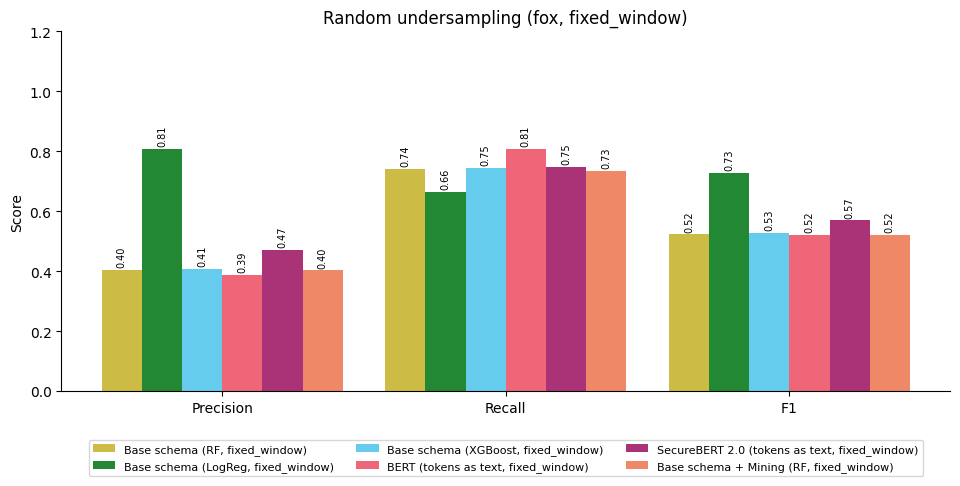

In [5]:
plot_baseline("random", "Random undersampling")

## Class-weighted (natural-ratio)

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/fox/fixed_window/class_weighted.png


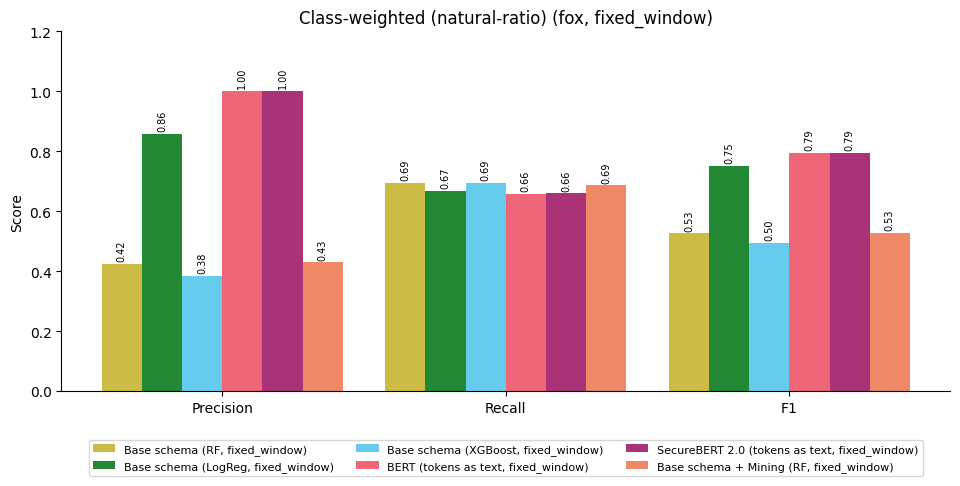

In [6]:
plot_baseline("class_weighted", "Class-weighted (natural-ratio)")

## Zero-shot

The one method without the two-condition structure (no training pool, no seeds) -- a single bar per metric from one deterministic run, not comparable to `plot_baseline()`'s per-condition grouped bars above.

In [7]:
def plot_zeroshot() -> None:
    name = next((n for n in RESULT_NAMES if n in results and is_zero_shot(results[n])), None)
    if name is None:
        print("No zero-shot results loaded -- run ait_ads_zeroshot.py first (check ZEROSHOT_MODEL_SLUG above matches the model you ran).")
        return

    metrics = ["precision", "recall", "f1"]
    data = results[name]
    values = [data[m] for m in metrics]

    fig, ax = plt.subplots(figsize=(4, 4))
    bars = ax.bar(metrics, values, color=COLORS.get(name))
    ax.bar_label(bars, fmt="%.3f", fontsize=9, padding=2)

    ax.set_xticklabels([m.capitalize() for m in metrics])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(f"{LABELS.get(name, name)} ({SCENARIO}, {GROUPING_METHOD})")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    save_path = FIGURES_DIR / "zeroshot.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Figure written to {save_path}")

    plt.show()


plot_zeroshot()

No zero-shot results loaded -- run ait_ads_zeroshot.py first (check ZEROSHOT_MODEL_SLUG above matches the model you ran).


## Anomaly (OneClassSVM, benign-only)

The other methods without the two-condition structure -- no training pool, no seeds, trained on benign rows only. Each reports `auc` alongside precision/recall/f1 (its headline metric, since scoring is threshold-free); not comparable to `plot_baseline()`'s per-condition grouped bars above. These are the only methods that produce a result for `harrison`/`santos`/`russellmitchell` -- see the intro cell's exclusion paragraph.

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/fox/fixed_window/anomaly.png


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_26850/4226850188.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.upper() if m == "auc" else m.capitalize() for m in metrics])


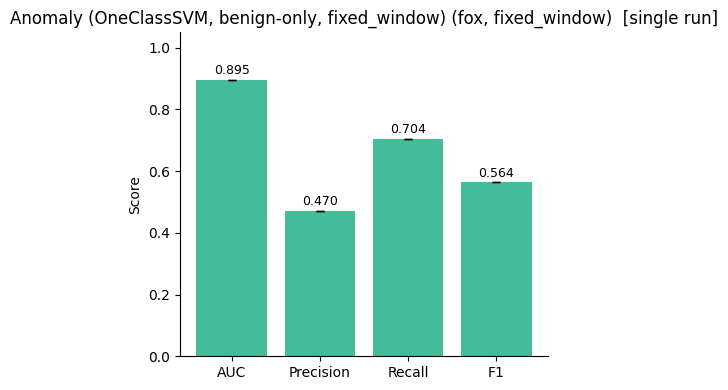

In [8]:
def plot_anomaly(name: str, save_name: str) -> None:
    if name not in results or not is_anomaly(results[name]):
        print(f"No anomaly results loaded for '{name}' -- run the matching script first.")
        return

    metrics = ["auc", "precision", "recall", "f1"]
    data = results[name]
    values = [data[m] for m in metrics]
    seeds = data.get("seeds") or []
    errs = [
        float(np.std([s[m] for s in seeds], ddof=1)) if len(seeds) > 1 else 0.0
        for m in metrics
    ]

    fig, ax = plt.subplots(figsize=(4.5, 4))
    bars = ax.bar(metrics, values, color=COLORS.get(name),
                  yerr=errs, capsize=3, error_kw={"lw": 0.8})
    ax.bar_label(bars, fmt="%.3f", fontsize=9, padding=2)

    ax.set_xticklabels([m.upper() if m == "auc" else m.capitalize() for m in metrics])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    n = len(seeds)
    ax.set_title(
        f"{LABELS.get(name, name)} ({SCENARIO}, {GROUPING_METHOD})"
        + (f"  [seed std, n={n}]" if n > 1 else "  [single run]")
    )
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    save_path = FIGURES_DIR / f"{save_name}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Figure written to {save_path}")

    plt.show()


plot_anomaly(f"ait_ads_anomaly_{GROUPING_METHOD}_{SCENARIO}_ocsvm", "anomaly")

## Anomaly (IsolationForest, benign-only)

Second anomaly-detector model family alongside the OneClassSVM above -- same benign-only fit, same test-side-only guard (also recovers `harrison`/`santos`/`russellmitchell`), same base schema, tree-based so no feature scaling.

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/fox/fixed_window/anomaly_iforest.png


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_26850/4226850188.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.upper() if m == "auc" else m.capitalize() for m in metrics])


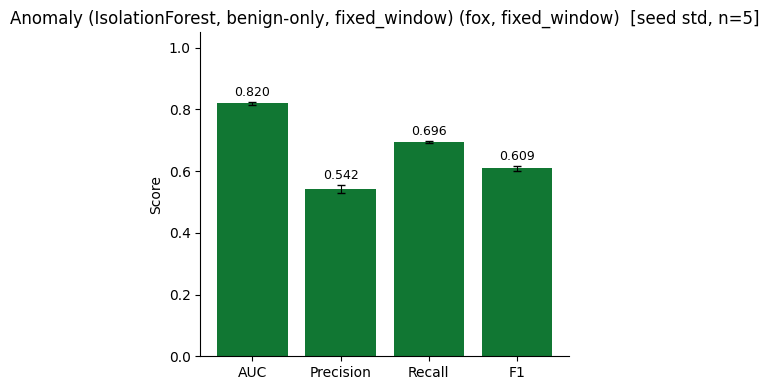

In [9]:
plot_anomaly(f"ait_ads_anomaly_{GROUPING_METHOD}_{SCENARIO}_iforest", "anomaly_iforest")

## Anomaly + Mining (OneClassSVM, benign-only)

Method 8's mined symbolic features on top of the reduced base schema, same benign-only `OneClassSVM` fit as the plain anomaly baseline above. Falls back to the plain anomaly baseline's numbers for `harrison`/`santos`/`russellmitchell` (0 mined predicates on a 100%-benign train split -- see the intro cell).

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/fox/fixed_window/mining_anomaly.png


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_26850/4226850188.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.upper() if m == "auc" else m.capitalize() for m in metrics])


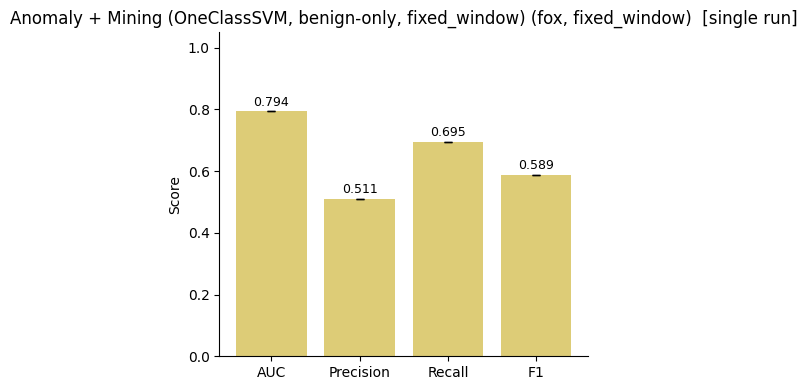

In [10]:
plot_anomaly(f"ait_ads_mining_anomaly_{GROUPING_METHOD}_{SCENARIO}_ocsvm", "mining_anomaly")

## Anomaly + Mining (IsolationForest, benign-only)

Method 9's mined symbolic features on the reduced base schema, `IsolationForest` fit on benign-only train rows -- the IsolationForest sibling of the mining anomaly baseline above, 5-seeded (`random_state=0..4`); error bars are the seed std.

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_26850/4226850188.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.upper() if m == "auc" else m.capitalize() for m in metrics])


Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/fox/fixed_window/mining_anomaly_iforest.png


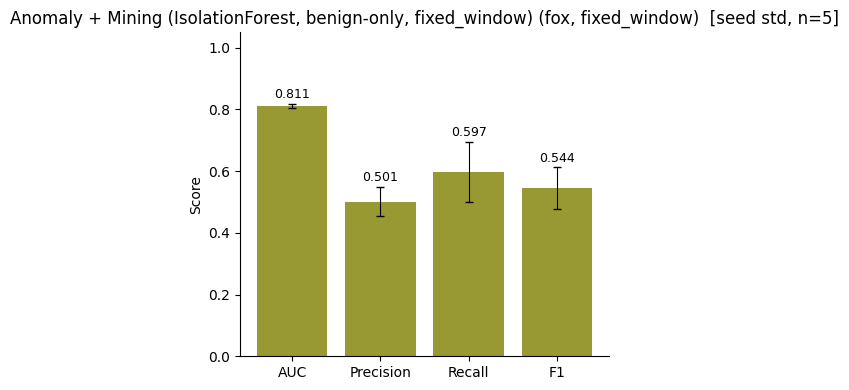

In [11]:
plot_anomaly(f"ait_ads_mining_anomaly_{GROUPING_METHOD}_{SCENARIO}_iforest", "mining_anomaly_iforest")

## Summary table

Tidy view of all loaded results for this scenario -- handy to copy straight into a slide.

In [12]:
CONDITION_LABELS = {
    "random": "Random undersampling",
    "class_weighted": "Class-weighted (natural-ratio)",
}

rows = []
for name, data in results.items():
    if is_zero_shot(data) or is_anomaly(data):
        rows.append({
            "method": LABELS.get(name, name),
            "condition": "(no training)",
            "auc": data.get("auc"),
            "precision": data["precision"],
            "recall": data["recall"],
            "f1": data["f1"],
        })
    else:
        for condition_key, condition_label in CONDITION_LABELS.items():
            if condition_key not in data:
                continue
            rows.append({
                "method": LABELS.get(name, name),
                "condition": condition_label,
                "auc": None,
                "precision": data[condition_key]["precision"],
                "recall": data[condition_key]["recall"],
                "f1": data[condition_key]["f1"],
            })

if not rows:
    print("No results loaded -- run the baseline scripts first.")
    summary_df = pd.DataFrame(columns=["method", "condition", "auc", "precision", "recall", "f1"])
else:
    summary_df = pd.DataFrame(rows).sort_values(["condition", "method"]).reset_index(drop=True)
    summary_csv_path = RESULTS_DIR / f"ait_ads_{SCENARIO}_{GROUPING_METHOD}_baseline_summary.csv"
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"Summary written to {summary_csv_path}")
summary_df

Summary written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/ait_ads_fox_fixed_window_baseline_summary.csv


,method,condition,auc,precision,recall,f1
0,"Anomaly (IsolationForest, benign-only, fixed_w...",(no training),0.820226,0.542348,0.695575,0.609398
1,"Anomaly (OneClassSVM, benign-only, fixed_window)",(no training),0.895237,0.470414,0.703540,0.563830
2,"Anomaly + Mining (IsolationForest, benign-only...",(no training),0.811036,0.500972,0.597345,0.544240
3,"Anomaly + Mining (OneClassSVM, benign-only, fi...",(no training),0.793950,0.511401,0.694690,0.589118
4,"BERT (tokens as text, fixed_window)",Class-weighted (natural-ratio),NaN,1.000000,0.657522,0.793374
5,"Base schema (LogReg, fixed_window)",Class-weighted (natural-ratio),NaN,0.857955,0.668142,0.751244
6,"Base schema (RF, fixed_window)",Class-weighted (natural-ratio),NaN,0.423569,0.693805,0.526002
7,"Base schema (XGBoost, fixed_window)",Class-weighted (natural-ratio),NaN,0.384804,0.694690,0.495268
8,"Base schema + Mining (RF, fixed_window)",Class-weighted (natural-ratio),NaN,0.429363,0.685841,0.528109
9,"SecureBERT 2.0 (tokens as text, fixed_window)",Class-weighted (natural-ratio),NaN,1.000000,0.659292,0.794667


## Anomaly detectors at a tuned operating point

The plots above are at each detector's default rejection rate (`nu` /
`contamination` = 0.05). This table reports each at the threshold that hits
**90% recall** (`training.workload.compute_workload_at_recall`, seed-averaged for
the IsolationForest rows): the precision an analyst sees at that cut, the
false-positive count on this scenario's test split, and `Workload -` = the
fraction of alerts the model lets them skip while still catching 90% of attacks.
`AUC` is the threshold-free ceiling. Writes
`results/ait_ads_{SCENARIO}_{GROUPING_METHOD}_anomaly_operating_points.tex`.

In [13]:
ANOMALY_OP_SPEC = [  # (label, model, result_key_suffix, mining?)
    ("Anomaly",          "OneClassSVM",     f"ait_ads_anomaly_{GROUPING_METHOD}_{SCENARIO}_ocsvm"),
    ("Anomaly",          "IsolationForest", f"ait_ads_anomaly_{GROUPING_METHOD}_{SCENARIO}_iforest"),
    ("Anomaly + mining", "OneClassSVM",     f"ait_ads_mining_anomaly_{GROUPING_METHOD}_{SCENARIO}_ocsvm"),
    ("Anomaly + mining", "IsolationForest", f"ait_ads_mining_anomaly_{GROUPING_METHOD}_{SCENARIO}_iforest"),
]
OP_TARGET = "0.90"  # target recall; JSON also carries 0.95 / 0.99

op_rows, op_tex = [], []
for label, model, key in ANOMALY_OP_SPEC:
    data = results.get(key)
    if data is None:
        print(f"[skip] {key} -- run the script first")
        continue
    wl = (data.get("workload_at_recall") or {}).get(OP_TARGET)
    op_rows.append({
        "Baseline": label, "Model": model,
        "AUC": round(data["auc"], 3),
        "F1 (default cut)": round(data["f1"], 3),
        "P@R>=.90": None if wl is None else round(wl["precision"], 3),
        "FP@R>=.90": None if wl is None else int(round(wl["fp"])),
        "Workload-@R>=.90": None if wl is None else round(wl["workload_reduction"], 3),
    })
    if wl is None:
        op_tex.append(f"{label} & {model} & {data['auc']:.3f} & {data['f1']:.3f} & -- & -- & --" + r" \\")
    else:
        op_tex.append(
            f"{label} & {model} & {data['auc']:.3f} & {data['f1']:.3f} & "
            f"{wl['precision']:.3f} & {wl['fp']:,.0f} & {wl['workload_reduction']:.3f}" + r" \\"
        )

op_df = pd.DataFrame(op_rows)

op_latex = (
    r"""\begin{table}[htbp]
\centering
\small
\caption{AIT-ADS anomaly detectors at a tuned operating point (scenario """
    + f"{SCENARIO}" + r""", grouping """ + f"{GROUPING_METHOD}" + r"""). \textbf{AUC} is
threshold-free ranking quality; \textbf{F1 (default cut)} is at the detector's own
$\nu$ / contamination $= 0.05$ rejection rate. The last three columns report the
detector at the threshold achieving 90\% recall: the precision at that cut, the
false-positive count on this scenario's test split, and \emph{Workload $-$} = the
fraction of alerts the analyst can skip while still catching 90\% of attacks.
IsolationForest rows are seed-averaged (5 seeds).}
\label{tab:ait-ads-""" + f"{SCENARIO}-{GROUPING_METHOD}" + r"""-anomaly-operating-points}
\begin{tabular}{llccrrr}
\toprule
\textbf{Baseline} & \textbf{Model} & \textbf{AUC} & \textbf{F1 (def.\ cut)} & \textbf{P@R$\geq$.90} & \textbf{FP@R$\geq$.90} & \textbf{Workload$-$@R$\geq$.90} \\
\midrule
"""
    + "\n".join(op_tex)
    + r"""
\bottomrule
\end{tabular}
\end{table}
"""
)

op_tex_path = RESULTS_DIR / f"ait_ads_{SCENARIO}_{GROUPING_METHOD}_anomaly_operating_points.tex"
op_tex_path.write_text(op_latex, encoding="utf-8")
print(f"Written to {op_tex_path}\n")
print(op_latex)
op_df

Written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/ait_ads_fox_fixed_window_anomaly_operating_points.tex

\begin{table}[htbp]
\centering
\small
\caption{AIT-ADS anomaly detectors at a tuned operating point (scenario fox, grouping fixed_window). \textbf{AUC} is
threshold-free ranking quality; \textbf{F1 (default cut)} is at the detector's own
$\nu$ / contamination $= 0.05$ rejection rate. The last three columns report the
detector at the threshold achieving 90\% recall: the precision at that cut, the
false-positive count on this scenario's test split, and \emph{Workload $-$} = the
fraction of alerts the analyst can skip while still catching 90\% of attacks.
IsolationForest rows are seed-averaged (5 seeds).}
\label{tab:ait-ads-fox-fixed_window-anomaly-operating-points}
\begin{tabular}{llccrrr}
\toprule
\textbf{Baseline} & \textbf{Model} & \textbf{AUC} & \textbf{F1 (def.\ cut)} & \textbf{P@R$\geq$.90} & \textbf{FP@R$\geq$.90} & \textbf{Workload$-$@R$

,Baseline,Model,AUC,F1 (default cut),P@R>=.90,FP@R>=.90,Workload-@R>=.90
0,Anomaly,OneClassSVM,0.895,0.564,0.205,812,0.670
1,Anomaly,IsolationForest,0.820,0.609,0.074,2810,0.019
2,Anomaly + mining,OneClassSVM,0.794,0.589,0.075,2759,0.036
3,Anomaly + mining,IsolationForest,0.811,0.544,0.076,2745,0.040
